# Pool-size fitting: multiple seeds × specified pool sizes

`RUN_SEEDS = [1,2,3,4,5]` のように複数seedを指定し、指定したpool sizeで各seedの結果を比較する notebook。

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data_poolsizefitting as ds

from data_poolsizefitting import (
    extract_or_locate_bundle,
    setup_openabm_colab, clone_and_build_openabm, run_openabm_exe,
    convert_raw_openabm_to_population_contacts, generate_synthetic_company_source_data,
    export_graph_samples, save_bundle, load_sample_from_root,
    build_analysis_dataset, compute_prior_methods,
    edge_weight_summary,
)

from function_poolsizefittiing import (
    get_default_params,
    restrict_dataset_to_positive_pools,
    run_sequential_sparse_reconstruction,
)

print("imports ok")


imports ok


In [13]:
# ============================================================
# 1. Data preparation settings
# ============================================================
# generate : generate population_all.csv / contacts_all.csv every run, then sample
# csv      : optional legacy mode; use existing population_all.csv / contacts_all.csv
# bundle   : optional; read an existing generated bundle/folder
DATA_SOURCE_MODE = "generate"

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "company_openabm_outputs"
POPULATION_ALL_CSV = OUTPUT_DIR / "population_all.csv"
CONTACTS_ALL_CSV = OUTPUT_DIR / "contacts_all.csv"

BUNDLE_PATH = None
EXTRACT_DIR = ROOT / "openabm_bundle"
SAVE_BUNDLE_PATH = ROOT / "openabm_bundle.zip"

OPENABM_DIR = ROOT / "OpenABM-Covid19"

# ------------------------------------------------------------
# Multiple seed setting
# ------------------------------------------------------------
# ここを変更する。
# 例: [1,2,3,4,5]
RUN_SEEDS = [1, 2, 3, 4, 5]

# 既存セルとの互換性のため、代表seedも定義しておく。
RUN_SEED = int(RUN_SEEDS[0])

OPENABM_DAYS = 60
OPENABM_N_TOTAL = 10000

# True: use the built-in simulation source generator so this notebook runs without external OpenABM files.
# False: run/build OpenABM, convert its raw output to population_all.csv / contacts_all.csv, then sample.
USE_SYNTHETIC_SOURCE_GENERATOR = False

# Company/workplace sample conditions
SAMPLE_SIZES = [3000]
TARGET_AGE_GROUPS = [2, 3, 4, 5]
WORKPLACE_CONTACT_TYPES = [1]
MAX_POSITIVE_RATE = 0.05
MIN_POSITIVE_COUNT = 30
TARGET_POSITIVE_COUNT_RANGE = (50, 120)
MIN_POSITIVE_COMPONENTS = 3
MIN_ISOLATED_POSITIVE = 0
MAX_LARGEST_POSITIVE_COMPONENT_RATIO = 0.60
MIN_POSITIVE_NEIGHBOR_RATIO = 1.0

CONTACT_TYPE_WEIGHTS = {
    0: 1.0,  # excluded in company sample
    1: 2.0,  # workplace-like contact
    2: 3.0,  # excluded in company sample
}

RUN_OPENABM_IF_NEEDED = True
SAVE_GENERATED_BUNDLE = False

# Select positives from positive-positive contact clusters as much as possible.
CLUSTER_POSITIVE_RATIO = 1.0

print("RUN_SEEDS:", RUN_SEEDS)
print("representative RUN_SEED:", RUN_SEED)


RUN_SEED: 1
OPENABM_SEED: 1


In [14]:
# ============================================================
# 2. Generate/load all data and export company/workplace sample for each seed
# ============================================================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_ROOTS = {}
generation_summaries = []

# OpenABMのビルドは重いので、複数seedでも一度だけ実行する。
if DATA_SOURCE_MODE == "generate" and (not USE_SYNTHETIC_SOURCE_GENERATOR) and RUN_OPENABM_IF_NEEDED:
    setup_openabm_colab()
    clone_and_build_openabm(OPENABM_DIR)

for run_seed in RUN_SEEDS:
    run_seed = int(run_seed)
    openabm_seed = int(run_seed)

    print(f"\n===== data preparation seed={run_seed} =====")

    if DATA_SOURCE_MODE == "generate":
        DATA_ROOT = OUTPUT_DIR / f"seed_{run_seed}"
        POPULATION_ALL_CSV = DATA_ROOT / "population_all.csv"
        CONTACTS_ALL_CSV = DATA_ROOT / "contacts_all.csv"
    else:
        DATA_ROOT = OUTPUT_DIR
        POPULATION_ALL_CSV = OUTPUT_DIR / "population_all.csv"
        CONTACTS_ALL_CSV = OUTPUT_DIR / "contacts_all.csv"

    DATA_ROOT.mkdir(parents=True, exist_ok=True)

    if DATA_SOURCE_MODE == "bundle":
        DATA_ROOT = extract_or_locate_bundle(zip_path=BUNDLE_PATH, extract_dir=EXTRACT_DIR)
        population_all = pd.read_csv(DATA_ROOT / "population_all.csv")
        contacts_all = pd.read_csv(DATA_ROOT / "contacts_all.csv")

    elif DATA_SOURCE_MODE == "csv":
        if not POPULATION_ALL_CSV.exists() or not CONTACTS_ALL_CSV.exists():
            raise FileNotFoundError(
                "DATA_SOURCE_MODE='csv' requires population_all.csv and contacts_all.csv "
                "under company_openabm_outputs/. Use DATA_SOURCE_MODE='generate' to create them."
            )
        population_all = pd.read_csv(POPULATION_ALL_CSV)
        contacts_all = pd.read_csv(CONTACTS_ALL_CSV)

    elif DATA_SOURCE_MODE == "generate":
        if USE_SYNTHETIC_SOURCE_GENERATOR:
            population_all, contacts_all = generate_synthetic_company_source_data(
                n_total=OPENABM_N_TOTAL,
                seed=openabm_seed,
                output_dir=DATA_ROOT,
            )
        else:
            if RUN_OPENABM_IF_NEEDED:
                raw_output_dir = run_openabm_exe(
                    OPENABM_DIR,
                    output_dir=DATA_ROOT / "openabm_raw_output",
                    n_total=OPENABM_N_TOTAL,
                    days=OPENABM_DAYS,
                    seed=openabm_seed,
                )
                population_all, contacts_all = convert_raw_openabm_to_population_contacts(
                    output_dir=raw_output_dir,
                    target_day=OPENABM_DAYS,
                )
                population_all.to_csv(POPULATION_ALL_CSV, index=False)
                contacts_all.to_csv(CONTACTS_ALL_CSV, index=False)
            else:
                raise ValueError("RUN_OPENABM_IF_NEEDED=False cannot generate source data.")
    else:
        raise ValueError(f"Unknown DATA_SOURCE_MODE: {DATA_SOURCE_MODE}")

    # Export the n=3000 company/workplace sample for this seed.
    generation_summary = export_graph_samples(
        population_all=population_all,
        contacts_all=contacts_all,
        output_dir=DATA_ROOT,
        sample_sizes=SAMPLE_SIZES,
        seed=openabm_seed,
        target_age_groups=TARGET_AGE_GROUPS,
        workplace_contact_types=WORKPLACE_CONTACT_TYPES,
        max_positive_rate=MAX_POSITIVE_RATE,
        min_positive_count=MIN_POSITIVE_COUNT,
        target_positive_count_range=TARGET_POSITIVE_COUNT_RANGE,
        min_positive_components=MIN_POSITIVE_COMPONENTS,
        min_isolated_positive=MIN_ISOLATED_POSITIVE,
        max_largest_positive_component_ratio=MAX_LARGEST_POSITIVE_COMPONENT_RATIO,
        min_positive_neighbor_ratio=MIN_POSITIVE_NEIGHBOR_RATIO,
    )

    generation_summary = generation_summary.copy()
    generation_summary["seed"] = run_seed
    generation_summaries.append(generation_summary)
    DATA_ROOTS[run_seed] = DATA_ROOT

    if SAVE_GENERATED_BUNDLE:
        save_bundle(DATA_ROOT, ROOT / f"openabm_bundle_seed{run_seed}.zip")

    print("DATA_ROOT:", DATA_ROOT)
    print("population_all:", POPULATION_ALL_CSV, POPULATION_ALL_CSV.exists())
    print("contacts_all:", CONTACTS_ALL_CSV, CONTACTS_ALL_CSV.exists())

generation_summary_all = pd.concat(generation_summaries, ignore_index=True) if generation_summaries else pd.DataFrame()
display(generation_summary_all)
print("DATA_ROOTS:", DATA_ROOTS)


,positive_positive_edges,positive_with_positive_neighbor,isolated_positive_count,positive_component_count,positive_cluster_component_count,largest_positive_component,largest_positive_component_ratio,positive_neighbor_ratio,sample_size,positive_count,...,contact_edges,contact_types,age_groups,path,attempts_used,sampling_conditions_met,target_age_groups,workplace_contact_types,max_positive_rate_condition,min_positive_count_condition
0,87,83,0,6,6,19,0.228916,1.0,3000,83,...,130,1,2;3;4;5,/content/company_openabm_outputs/seed_1/sample...,1,True,2;3;4;5,1,0.05,30


DATA_ROOT: /content/company_openabm_outputs/seed_1
population_all: /content/company_openabm_outputs/seed_1/population_all.csv True
contacts_all: /content/company_openabm_outputs/seed_1/contacts_all.csv True


In [23]:
# ============================================================
# 3. Pool-size fitting settings
# ============================================================

# Sample size
SAMPLE_SIZE = 3000

# Method setting
TARGET_METHOD = "symptom_count_plus_graph"

# 既存コードとの互換性のため、SEEDSも定義
SEEDS = [int(s) for s in RUN_SEEDS]

# Pool sizes to evaluate
# 「指定したプールサイズで各シードを比較」したい場合はここを変える。
# 例: [100] / [80, 100, 120] / [1] + list(range(10,301,10))
POOL_SIZE_SWEEP_RANGE = [100]

# baselineとして「全員を1つのpoolに入れる」pool_size=SAMPLE_SIZEを追加したい場合だけ True
INCLUDE_BASELINE_POOL_SIZE = False
BASELINE_POOL_SIZE = int(SAMPLE_SIZE)

if INCLUDE_BASELINE_POOL_SIZE:
    POOL_SIZE_SWEEP_RANGE = list(POOL_SIZE_SWEEP_RANGE) + [BASELINE_POOL_SIZE]

# 重複除去・昇順化
POOL_SIZE_SWEEP_RANGE = sorted(set(int(x) for x in POOL_SIZE_SWEEP_RANGE))

# Plot settings
FIXED_SEED_FOR_POOLSIZE_PLOT = int(SEEDS[0])
FIXED_POOL_SIZE_FOR_SEED_PLOT = int(POOL_SIZE_SWEEP_RANGE[0])

# Symptom-generation / graph prior settings
CLUSTER_SYMPTOM_STRENGTH = 0.95
FORCE_SYMPTOM_REGENERATION = True
TARGET_POSITIVE_SYMPTOMATIC_RATE = 0.92

C_EDGE_MIN_WEIGHT = 2.0
NEG_COVID_LEAK_PROB = 0.0
NONCOVID_BASE_PROB = 0.0
POS_NONCOVID_PROB = 0.0

BETA_SYMPTOM = 1.0
GRAPH_WEIGHT = 1.0
GRAPH_NORMALIZATION = "neighbor_symptom_sum_div_max_symptoms"
CLIP_GRAPH_SCORE = False

# If True, after first-stage pooled qPCR, remove negative-only individuals and reconstruct only within positive pools.
USE_POSITIVE_POOL_SUBPROBLEM = True

# None means run until all positives are found.
POOL_SIZE_SWEEP_MAX_ROUNDS = None

# Output files
RESULTS_DIR = ROOT / "poolsizefitting_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

seed_tag = "seeds_" + "-".join(map(str, SEEDS))
pool_tag = "pools_" + "-".join(map(str, POOL_SIZE_SWEEP_RANGE[:5])) + ("_etc" if len(POOL_SIZE_SWEEP_RANGE) > 5 else "")

POOLSIZE_FITTING_CSV = RESULTS_DIR / f"poolsize_fitting_symptom_count_plus_graph_{seed_tag}_{pool_tag}.csv"
POOLSIZE_FITTING_SUMMARY_CSV = RESULTS_DIR / f"poolsize_fitting_summary_symptom_count_plus_graph_{seed_tag}_{pool_tag}.csv"
POOLSIZE_FIXED_SEED_PNG = RESULTS_DIR / f"poolsize_fitting_fixed_seed{FIXED_SEED_FOR_POOLSIZE_PLOT}_{pool_tag}.png"
SEED_FIXED_POOLSIZE_PNG = RESULTS_DIR / f"seed_sensitivity_fixed_poolsize{FIXED_POOL_SIZE_FOR_SEED_PLOT}_{seed_tag}.png"
OVERVIEW_PNG = RESULTS_DIR / f"poolsize_fitting_overview_{seed_tag}_{pool_tag}.png"

print("target method:", TARGET_METHOD)
print("run seeds:", SEEDS)
print("pool sizes:", POOL_SIZE_SWEEP_RANGE)
print("fixed pool size for seed comparison:", FIXED_POOL_SIZE_FOR_SEED_PLOT)
print("results dir:", RESULTS_DIR.resolve())
print("output csv:", POOLSIZE_FITTING_CSV)


target method: symptom_count_plus_graph
run seed: 1
pool sizes: [1, 10, 110, 210, 310, 410, 510, 610, 710, 810, 910, 1010, 1110, 1210, 1310, 1410, 1510, 1610, 1710, 1810, 1910, 2010, 2110, 2210, 2310, 2410, 2510, 2610, 2710, 2810, 2910]
results dir: /content/poolsizefitting_results
output csv: /content/poolsizefitting_results/poolsize_fitting_symptom_count_plus_graph_seed1.csv


In [24]:
# ============================================================
# 4. Load company samples for each seed
# ============================================================

SAMPLES = {}

for run_seed in SEEDS:
    DATA_ROOT = DATA_ROOTS[int(run_seed)]
    population, contacts, sample_dir = load_sample_from_root(DATA_ROOT, sample_size=SAMPLE_SIZE)
    SAMPLES[int(run_seed)] = {
        "population": population,
        "contacts": contacts,
        "sample_dir": sample_dir,
    }

    print(f"\n===== loaded seed={run_seed} =====")
    print("sample_dir:", sample_dir)
    print("n:", len(population))
    print("contacts:", len(contacts))

print("\npool sizes:", POOL_SIZE_SWEEP_RANGE)
print("seeds:", SEEDS)


sample_dir: /content/company_openabm_outputs/seed_1/samples/company_n3000_maxpos5pct_work
n: 3000
contacts: 130
pool sizes: [1, 10, 110, 210, 310, 410, 510, 610, 710, 810, 910, 1010, 1110, 1210, 1310, 1410, 1510, 1610, 1710, 1810, 1910, 2010, 2110, 2210, 2310, 2410, 2510, 2610, 2710, 2810, 2910]
run seed: 1


In [25]:

# ============================================================
# 5. Helper: run one method for one seed and one pool size
# ============================================================

def run_one_seed_poolsize(
    population,
    contacts,
    seed: int,
    pool_size: int,
    target_method: str = TARGET_METHOD,
    verbose: bool = True,
) -> dict:
    """Run one pool-size experiment for one seed using only target_method."""

    params = get_default_params(n=len(population), pool_size=int(pool_size))

    full_dataset = build_analysis_dataset(
        population,
        contacts,
        params=params,
        pool_size=int(pool_size),
        cluster_symptom_strength=CLUSTER_SYMPTOM_STRENGTH,
        seed=int(seed),
        force_symptom_regeneration=FORCE_SYMPTOM_REGENERATION,
        contact_type_weights=CONTACT_TYPE_WEIGHTS,
        strong_edge_threshold=C_EDGE_MIN_WEIGHT,
        neg_covid_leak_prob=NEG_COVID_LEAK_PROB,
        noncovid_base_prob=NONCOVID_BASE_PROB,
        pos_noncovid_prob=POS_NONCOVID_PROB,
        target_positive_symptomatic_rate=TARGET_POSITIVE_SYMPTOMATIC_RATE,
    )

    analysis_dataset = (
        restrict_dataset_to_positive_pools(full_dataset)
        if USE_POSITIVE_POOL_SUBPROBLEM
        else full_dataset
    )

    initial_pool_count = int(analysis_dataset.get("initial_pool_count", len(full_dataset["pools"])))
    positive_pool_count = int(analysis_dataset.get("positive_pool_count", len(full_dataset["pools"])))
    candidate_count = int(len(analysis_dataset.get("x_true", [])))

    if candidate_count == 0:
        row = {
            "seed": int(seed),
            "pool_size": int(pool_size),
            "method": target_method,
            "initial_pool_count": initial_pool_count,
            "positive_pool_constraint_count": positive_pool_count,
            "candidate_count": 0,
            "true_positive_count": 0,
            "individual_test_count": 0,
            "total_test_cost": initial_pool_count,
            "status": "ok_no_positive_pool",
        }
        if verbose:
            print(
                f"seed={seed} pool_size={pool_size}: total={row['total_test_cost']} "
                f"candidates=0 positive_pools={positive_pool_count}"
            )
        return row

    priors, _, _ = compute_prior_methods(
        analysis_dataset,
        beta_symptom=BETA_SYMPTOM,
        graph_weight=GRAPH_WEIGHT,
        graph_normalization=GRAPH_NORMALIZATION,
        clip_graph_score=CLIP_GRAPH_SCORE,
    )

    if target_method not in priors:
        raise KeyError(f"{target_method} not found in priors. Available methods: {list(priors.keys())}")

    max_rounds = candidate_count if POOL_SIZE_SWEEP_MAX_ROUNDS is None else int(POOL_SIZE_SWEEP_MAX_ROUNDS)

    res = run_sequential_sparse_reconstruction(
        analysis_dataset,
        mu=priors[target_method],
        label=target_method,
        max_rounds=max_rounds,
    )

    row = {
        "seed": int(seed),
        "pool_size": int(pool_size),
        "method": target_method,
        "initial_pool_count": int(res["pool_count"]),
        "positive_pool_constraint_count": int(res.get("positive_pool_constraint_count", positive_pool_count)),
        "candidate_count": candidate_count,
        "true_positive_count": int(
            (np.asarray(analysis_dataset["x_true"]) >= analysis_dataset["params"]["x_min_positive"]).sum()
        ),
        "individual_test_count": int(res["inspection_count"]),
        "total_test_cost": int(res["total_test_cost"]),
        "status": "ok",
    }

    if verbose:
        print(
            f"seed={seed} pool_size={pool_size}: total={row['total_test_cost']} "
            f"candidates={row['candidate_count']} positive_pools={row['positive_pool_constraint_count']}"
        )

    return row


In [26]:
# ============================================================
# 6. Run: multiple seeds × specified pool sizes
# ============================================================

rows = []

for seed in SEEDS:
    seed = int(seed)
    population = SAMPLES[seed]["population"]
    contacts = SAMPLES[seed]["contacts"]

    print(f"\n===== seed={seed} =====")
    for pool_size in POOL_SIZE_SWEEP_RANGE:
        try:
            row = run_one_seed_poolsize(
                population=population,
                contacts=contacts,
                seed=seed,
                pool_size=pool_size,
                target_method=TARGET_METHOD,
                verbose=True,
            )
        except Exception as e:
            row = {
                "seed": int(seed),
                "pool_size": int(pool_size),
                "method": TARGET_METHOD,
                "initial_pool_count": np.nan,
                "positive_pool_constraint_count": np.nan,
                "candidate_count": np.nan,
                "true_positive_count": np.nan,
                "individual_test_count": np.nan,
                "total_test_cost": np.nan,
                "status": f"error: {type(e).__name__}: {e}",
            }
            print(f"seed={seed} pool_size={pool_size}: ERROR {type(e).__name__}: {e}")

        rows.append(row)

poolsize_fitting_df = pd.DataFrame(rows)
poolsize_fitting_df.to_csv(POOLSIZE_FITTING_CSV, index=False)

display(poolsize_fitting_df)
print("saved:", POOLSIZE_FITTING_CSV)
print("exists:", POOLSIZE_FITTING_CSV.exists(), "bytes:", POOLSIZE_FITTING_CSV.stat().st_size if POOLSIZE_FITTING_CSV.exists() else None)



===== seed=1 =====
seed=1 pool_size=1: total=3082 candidates=82 positive_pools=82
seed=1 pool_size=10: total=382 candidates=740 positive_pools=74
seed=1 pool_size=110: total=196 candidates=2780 positive_pools=26
seed=1 pool_size=210: total=106 candidates=3000 positive_pools=15
seed=1 pool_size=310: total=247 candidates=3000 positive_pools=10
seed=1 pool_size=410: total=166 candidates=3000 positive_pools=8
seed=1 pool_size=510: total=481 candidates=3000 positive_pools=6
seed=1 pool_size=610: total=588 candidates=3000 positive_pools=5
seed=1 pool_size=710: total=193 candidates=3000 positive_pools=5
seed=1 pool_size=810: total=597 candidates=3000 positive_pools=4
seed=1 pool_size=910: total=301 candidates=3000 positive_pools=4
seed=1 pool_size=1010: total=992 candidates=3000 positive_pools=3
seed=1 pool_size=1110: total=800 candidates=3000 positive_pools=3
seed=1 pool_size=1210: total=606 candidates=3000 positive_pools=3
seed=1 pool_size=1310: total=410 candidates=3000 positive_pools=3
s

,seed,pool_size,method,initial_pool_count,positive_pool_constraint_count,candidate_count,true_positive_count,individual_test_count,total_test_cost,status
0,1,1,symptom_count_plus_graph,3000,82,82,82,82,3082,ok
1,1,10,symptom_count_plus_graph,300,74,740,82,82,382,ok
2,1,110,symptom_count_plus_graph,28,26,2780,83,168,196,ok
3,1,210,symptom_count_plus_graph,15,15,3000,83,91,106,ok
4,1,310,symptom_count_plus_graph,10,10,3000,83,237,247,ok
5,1,410,symptom_count_plus_graph,8,8,3000,83,158,166,ok
6,1,510,symptom_count_plus_graph,6,6,3000,83,475,481,ok
7,1,610,symptom_count_plus_graph,5,5,3000,83,583,588,ok
8,1,710,symptom_count_plus_graph,5,5,3000,83,188,193,ok
9,1,810,symptom_count_plus_graph,4,4,3000,83,593,597,ok


saved: /content/poolsizefitting_results/poolsize_fitting_symptom_count_plus_graph_seed1.csv
exists: True bytes: 1863


In [27]:

# ============================================================
# 7. Summary by pool size
# ============================================================

ok_df = poolsize_fitting_df[
    poolsize_fitting_df["status"].astype(str).str.startswith("ok")
].copy()

summary_df = (
    ok_df
    .groupby(["pool_size", "method"], as_index=False)
    .agg(
        n_runs=("total_test_cost", "count"),
        mean_total_tests=("total_test_cost", "mean"),
        std_total_tests=("total_test_cost", "std"),
        min_total_tests=("total_test_cost", "min"),
        max_total_tests=("total_test_cost", "max"),
        median_total_tests=("total_test_cost", "median"),
        mean_initial_pool_count=("initial_pool_count", "mean"),
        mean_individual_test_count=("individual_test_count", "mean"),
        mean_positive_pools=("positive_pool_constraint_count", "mean"),
        mean_candidate_count=("candidate_count", "mean"),
    )
    .sort_values(["mean_total_tests", "pool_size"])
)

summary_df.to_csv(POOLSIZE_FITTING_SUMMARY_CSV, index=False)

display(summary_df)
print("saved:", POOLSIZE_FITTING_SUMMARY_CSV)

if len(summary_df):
    best = summary_df.iloc[0]
    print(
        "best by mean total tests:",
        f"pool_size={int(best['pool_size'])}",
        f"mean_total_tests={best['mean_total_tests']:.2f}",
    )


,pool_size,method,n_runs,mean_total_tests,std_total_tests,min_total_tests,max_total_tests,median_total_tests,mean_initial_pool_count,mean_individual_test_count,mean_positive_pools,mean_candidate_count
3,210,symptom_count_plus_graph,1,106.0,NaN,106,106,106.0,15.0,91.0,15.0,3000.0
30,2910,symptom_count_plus_graph,1,122.0,NaN,122,122,122.0,2.0,120.0,2.0,3000.0
5,410,symptom_count_plus_graph,1,166.0,NaN,166,166,166.0,8.0,158.0,8.0,3000.0
8,710,symptom_count_plus_graph,1,193.0,NaN,193,193,193.0,5.0,188.0,5.0,3000.0
2,110,symptom_count_plus_graph,1,196.0,NaN,196,196,196.0,28.0,168.0,26.0,2780.0
15,1410,symptom_count_plus_graph,1,211.0,NaN,211,211,211.0,3.0,208.0,3.0,3000.0
29,2810,symptom_count_plus_graph,1,220.0,NaN,220,220,220.0,2.0,218.0,2.0,3000.0
4,310,symptom_count_plus_graph,1,247.0,NaN,247,247,247.0,10.0,237.0,10.0,3000.0
10,910,symptom_count_plus_graph,1,301.0,NaN,301,301,301.0,4.0,297.0,4.0,3000.0
28,2710,symptom_count_plus_graph,1,319.0,NaN,319,319,319.0,2.0,317.0,2.0,3000.0


saved: /content/poolsizefitting_results/poolsize_fitting_summary_symptom_count_plus_graph_seed1.csv
best by mean total tests: pool_size=210 mean_total_tests=106.00


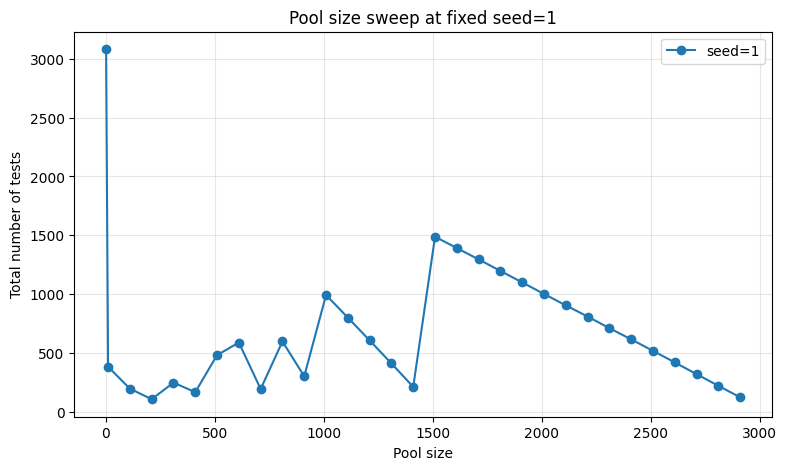

saved: /content/poolsizefitting_results/poolsize_fitting_fixed_seed1.png


In [28]:
# ============================================================
# 8. Graph 1: fixed seed, x=pool size, y=total tests
# ============================================================

fixed_seed_df = ok_df[ok_df["seed"] == FIXED_SEED_FOR_POOLSIZE_PLOT].copy()
fixed_seed_df["pool_size"] = pd.to_numeric(fixed_seed_df["pool_size"])
fixed_seed_df["total_test_cost"] = pd.to_numeric(fixed_seed_df["total_test_cost"])
fixed_seed_df = fixed_seed_df.sort_values("pool_size")

if fixed_seed_df.empty:
    print(f"No ok results for seed={FIXED_SEED_FOR_POOLSIZE_PLOT}")
else:
    fig, ax = plt.subplots(figsize=(9, 5))

    baseline_df = fixed_seed_df[fixed_seed_df["pool_size"] == BASELINE_POOL_SIZE].copy()
    plot_df = fixed_seed_df[fixed_seed_df["pool_size"] != BASELINE_POOL_SIZE].copy()

    ax.plot(
        plot_df["pool_size"],
        plot_df["total_test_cost"],
        marker="o",
        label=f"seed={FIXED_SEED_FOR_POOLSIZE_PLOT}",
    )

    if INCLUDE_BASELINE_POOL_SIZE and not baseline_df.empty:
        baseline_tests = float(baseline_df["total_test_cost"].iloc[0])
        ax.axhline(
            y=baseline_tests,
            linestyle="--",
            linewidth=1.8,
            label=f"baseline pool_size={BASELINE_POOL_SIZE}: {baseline_tests:.0f} tests",
        )
        if not plot_df.empty:
            ax.text(plot_df["pool_size"].max(), baseline_tests, f"  baseline={baseline_tests:.0f}", va="center")

    if not plot_df.empty:
        ax.set_xlim(plot_df["pool_size"].min() - 5, plot_df["pool_size"].max() + 10)

    ax.set_xlabel("Pool size")
    ax.set_ylabel("Total number of tests")
    ax.set_title(f"Pool size sweep at fixed seed={FIXED_SEED_FOR_POOLSIZE_PLOT}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.savefig(POOLSIZE_FIXED_SEED_PNG, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    print("saved:", POOLSIZE_FIXED_SEED_PNG)


In [29]:
# ============================================================
# 9. Graph 2: fixed pool size, x=seed, y=total tests
# ============================================================

fixed_pool_df = ok_df[ok_df["pool_size"] == FIXED_POOL_SIZE_FOR_SEED_PLOT].copy()
fixed_pool_df["seed"] = pd.to_numeric(fixed_pool_df["seed"])
fixed_pool_df["total_test_cost"] = pd.to_numeric(fixed_pool_df["total_test_cost"])
fixed_pool_df = fixed_pool_df.sort_values("seed")

display(fixed_pool_df)

if fixed_pool_df.empty:
    print(f"No ok results for pool_size={FIXED_POOL_SIZE_FOR_SEED_PLOT}")
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(
        fixed_pool_df["seed"],
        fixed_pool_df["total_test_cost"],
        marker="o",
        label=f"pool_size={FIXED_POOL_SIZE_FOR_SEED_PLOT}",
    )

    ax.set_xlabel("Seed")
    ax.set_ylabel("Total number of tests")
    ax.set_title(f"Seed sensitivity at fixed pool_size={FIXED_POOL_SIZE_FOR_SEED_PLOT}")
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.savefig(SEED_FIXED_POOLSIZE_PNG, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    print("saved:", SEED_FIXED_POOLSIZE_PNG)


,seed,pool_size,method,initial_pool_count,positive_pool_constraint_count,candidate_count,true_positive_count,individual_test_count,total_test_cost,status


Single-seed mode: seed sensitivity plot is skipped. Merge multiple seed CSVs later.


baseline pool_size=2910: total_test_cost=122


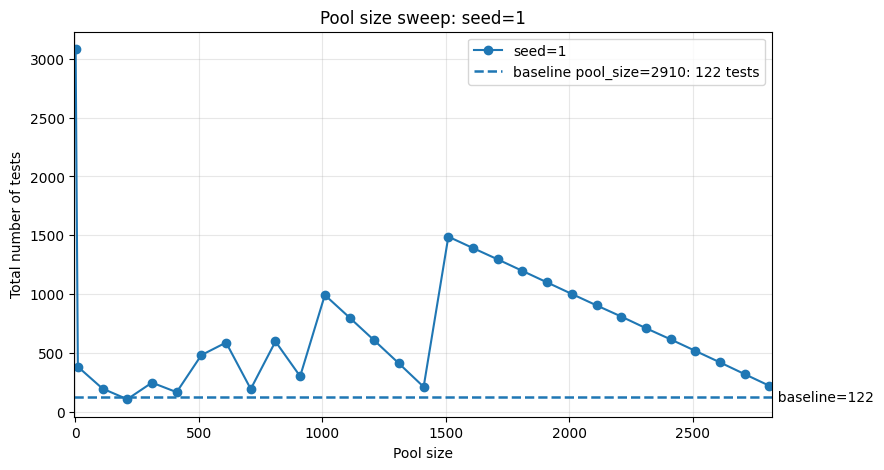

saved: /content/poolsizefitting_results/poolsize_fitting_overview_seed1.png


In [33]:
# ============================================================
# 10. Overview: multiple seeds × specified pool sizes
# ============================================================

if ok_df.empty:
    print("No ok results to plot.")
else:
    fig, ax = plt.subplots(figsize=(9, 5))

    sub = ok_df.copy()
    sub["seed"] = pd.to_numeric(sub["seed"])
    sub["pool_size"] = pd.to_numeric(sub["pool_size"])
    sub["total_test_cost"] = pd.to_numeric(sub["total_test_cost"])

    plot_df_all = sub[sub["pool_size"] != BASELINE_POOL_SIZE].copy()

    # pool size が複数ある場合：seedごとの折れ線
    if plot_df_all["pool_size"].nunique() >= 2:
        for seed, g in plot_df_all.groupby("seed"):
            g = g.sort_values("pool_size")
            ax.plot(g["pool_size"], g["total_test_cost"], marker="o", label=f"seed={int(seed)}")
        ax.set_xlabel("Pool size")
        ax.set_title("Pool size sweep across seeds")

    # pool size が1つだけの場合：seed比較
    else:
        plot_df_all = plot_df_all.sort_values("seed")
        ax.plot(
            plot_df_all["seed"],
            plot_df_all["total_test_cost"],
            marker="o",
            label=f"pool_size={int(plot_df_all['pool_size'].iloc[0])}" if not plot_df_all.empty else "pool_size",
        )
        ax.set_xlabel("Seed")
        ax.set_title(f"Seed sensitivity at pool_size={FIXED_POOL_SIZE_FOR_SEED_PLOT}")

    ax.set_ylabel("Total number of tests")
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.savefig(OVERVIEW_PNG, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()

    print("saved:", OVERVIEW_PNG)
